In [1]:
import os

PROJECT_PATH = '/home/sbehnam/Project/grasp2sim'
SCENE_DIR = os.path.join(PROJECT_PATH, 'scenes')
POSES_DIR = os.path.join(PROJECT_PATH, 'poses')

import sys
sys.path.append(PROJECT_PATH)

os.environ['MUJOCO_GL'] = 'egl'

import mujoco
import mediapy as media
import numpy as np
from tqdm import tqdm
from scipy.spatial.transform import Rotation as R

In [2]:
from scenes.grasp2scene import Scene, GRASPNET_SCENE_ROOT, MODEL_DIR, HAND_ASSETS

object_id = 5

XML_PATH = f'{SCENE_DIR}/scene_{object_id}-2_0000.xml'

s = Scene(scene_dir=GRASPNET_SCENE_ROOT, model_dir=MODEL_DIR, hand_assets=HAND_ASSETS)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
# s.save_xml(XML_PATH, obj_indexes=object_id)

Saved → /home/sbehnam/Project/grasp2sim/scenes/scene_5-2_0000.xml


In [3]:
from grasp_sim import GraspHand, Executors

hand = GraspHand(grasps_npy="/home/sbehnam/Project/data/scenes/scene_0000/some_banana_grasp.npy", debug=True,
                  debug_log_every=1)
hand.reset_scene()
# hand.step(30)
hand.capture()

media.show_video(hand.frames, fps=8)

In [4]:
from graspnetAPI import GraspGroup
import copy

def filter_by_object_id(grasps_group : GraspGroup, object_id) -> GraspGroup:

    filtered_grasp_group_array = copy.deepcopy(grasps_group.grasp_group_array)

    filter_grasp_group = GraspGroup(filtered_grasp_group_array[filtered_grasp_group_array[:, 16] == object_id])

    return filter_grasp_group

one_object_grasps = filter_by_object_id(hand.gg, 5)

sample_pose = GraspGroup()

sample_pose.grasp_group_array = one_object_grasps.grasp_group_array[2:3]

sample_pose

----------
Grasp Group, Number=1:
Grasp: score:0.7000000476837158, width:0.04720092937350273, height:0.019999999552965164, depth:0.009999999776482582, translation:[-0.10236878 -0.08849756  0.45573398]
rotation:
[[-0.12598054 -0.99199384  0.00877897]
 [-0.71744215  0.08499432 -0.69141352]
 [ 0.68513179 -0.09340308 -0.72240585]]
object id:5
----------

In [5]:
from graspnetAPI import GraspNet

GRAPNET_DATASET = "/home/sbehnam/Project/data/"

g_net = GraspNet(root=GRAPNET_DATASET, camera='kinect', split='custom', sceneIds=[0])
cloud = g_net.loadScenePointCloud(sceneId=0, camera='kinect', annId=0, align=False)

Loading data path...: 100%|██████████| 1/1 [00:00<00:00, 101.50it/s]

[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x572cf9ca9c70 (threading is enabled)
EGL(1.5)
OpenGL(4.1)


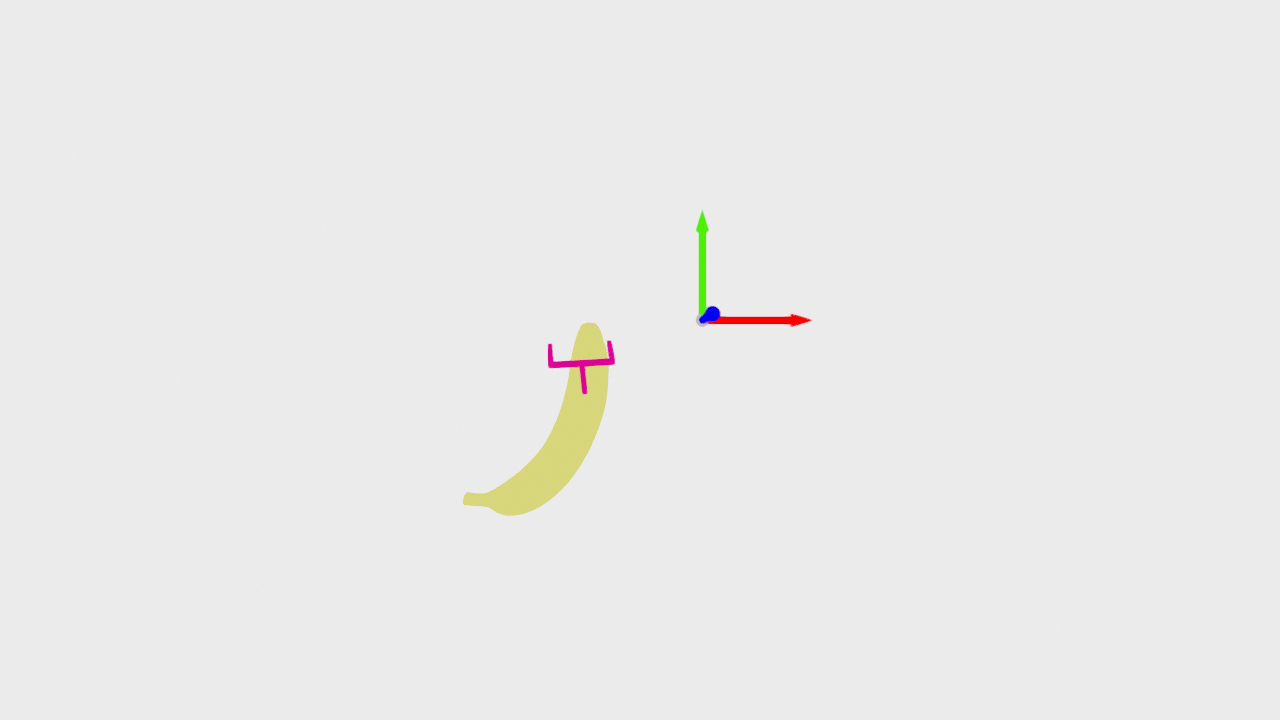

In [7]:
import open3d as o3d
from utils.utils import render_geometries_to_notebook
import copy

mesh = o3d.io.read_triangle_mesh("/home/sbehnam/models/005/nontextured.stl")
mesh.compute_vertex_normals()
mesh.paint_uniform_color([0.7, 0.7, 0.2])

from graspnetAPI.utils.utils import parse_posevector

for pv in s.posevectors:

    obj_idx, obj_pose_cam = parse_posevector(pv)
    if obj_idx == object_id:
        mesh.transform(s.camera_pose @ obj_pose_cam)
        break;

# Table coordinate frame for reference
frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1)

test_pose = copy.deepcopy(sample_pose)

test_pose.transform(s.camera_pose)
grippers = test_pose.to_open3d_geometry_list()

render_geometries_to_notebook([frame, mesh] + grippers, save_path="temp-scene.png")

[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x572cf9ca9c70 (threading is enabled)
EGL(1.5)
OpenGL(4.1)


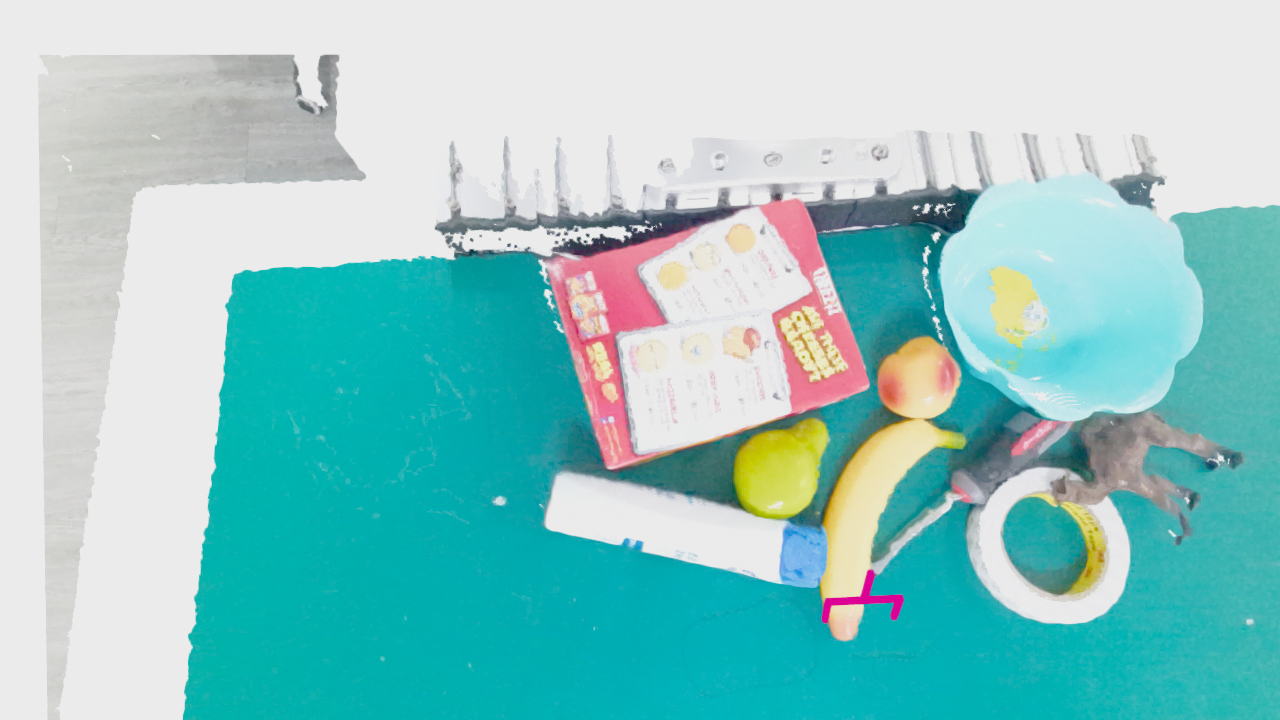

In [8]:
from utils.utils import render_graspnet_scene_notebook

geometries = []
geometries.append(cloud)
geometries += sample_pose.to_open3d_geometry_list()

render_graspnet_scene_notebook(geometries, width=1280, height=720, shift_x=-0.2, save_path="temp-scene.png")

In [5]:
hand.frames = []

hand.cam.azimuth = -120
hand.cam.distance = 0.5
hand.cam.lookat = [-0.2, -0.15, 0]

g          = sample_pose[0]
t_w        = hand.grasp_to_world(g)

quat       = hand.to_mujoco_quat(g.rotation_matrix)
approach_w = hand.T_CAM2TABLE[:3, :3] @ g.rotation_matrix[:, 0]

theo_mid_cam = g.translation + g.depth * g.rotation_matrix[:, 0]
theo_mid = hand.T_CAM2TABLE[:3, :3] @ theo_mid_cam + hand.T_CAM2TABLE[:3, 3]

# ---

m_tw   = mujoco.mj_name2id(hand.model, mujoco.mjtObj.mjOBJ_BODY, "marker_tw")
m_theo = mujoco.mj_name2id(hand.model, mujoco.mjtObj.mjOBJ_BODY, "marker_theo")

hand.reset_scene()

hand.sim.mocap_pos[hand.model.body_mocapid[m_tw]]   = t_w
hand.sim.mocap_pos[hand.model.body_mocapid[m_theo]] = theo_mid
mujoco.mj_forward(hand.model, hand.sim)
hand.capture()

media.show_video(hand.frames, fps=3)

In [6]:
from grasp_sim import Executors

hand_id = mujoco.mj_name2id(hand.model, mujoco.mjtObj.mjOBJ_BODY, "hand")
left_tip_site_id  = hand.model.site("left_tip").id
right_tip_site_id = hand.model.site("right_tip").id

t_w        = hand.grasp_to_world(g)

quat       = hand.to_mujoco_quat(g.rotation_matrix)
approach_w = hand.T_CAM2TABLE[:3, :3] @ g.rotation_matrix[:, 0]

# hand.reset_scene()
# hand.open_gripper(min(0.08, g.width + 0.015))   # small slack
hand.open_gripper(0.2)  # open wide for visualization
hand.step(30)
hand.capture()

pre_grasp_pose = t_w - 0.12 * approach_w

hand.move_hand(pre_grasp_pose, quat, n_steps=200, record=True)

hand.move_hand(t_w, quat, n_steps=100, record=True, substeps=8)

hand.close_gripper()
hand.step(200, record=True)

hand.move_hand(pre_grasp_pose, quat, n_steps=200, record=True)

hand.move_hand(pre_grasp_pose + np.array([0.0, 0.0, 0.25]), quat,
                      n_steps=200, record=True)

# intended vs actual
print(f"target  t_w = {np.round(t_w,4)}")
print(f"actual hand = {np.round(hand.sim.xpos[hand_id],4)}")

# compute actual fingertip midpoint in world
tipL = hand.sim.site_xpos[left_tip_site_id]   # or xpos of left pad body
tipR = hand.sim.site_xpos[right_tip_site_id]
actual_mid = 0.5*(tipL + tipR)

print(f"actual mid  = {np.round(actual_mid,4)}")
print(f"error       = {np.linalg.norm(actual_mid - t_w)*1000:.1f} mm")

media.show_video(hand.frames, fps=3)

target  t_w = [-0.0935 -0.0801  0.1097]
actual hand = [-0.0775 -0.1432  0.4605]
actual mid  = [-0.0912 -0.0891  0.3741]
error       = 264.5 mm


This browser does not support the video tag.


In [7]:
hand.frames = []

hand.cam.elevation = -30
hand.cam.azimuth = -120
hand.cam.distance = 0.5
hand.cam.lookat = [-0.2, -0.15, 0]

g          = one_object_grasps[1]
t_w        = hand.grasp_to_world(g)

quat       = hand.to_mujoco_quat(g.rotation_matrix)
approach_w = hand.T_CAM2TABLE[:3, :3] @ g.rotation_matrix[:, 0]

theo_mid_cam = g.translation + g.depth * g.rotation_matrix[:, 0]
theo_mid = hand.T_CAM2TABLE[:3, :3] @ theo_mid_cam + hand.T_CAM2TABLE[:3, 3]

# ---

m_tw   = mujoco.mj_name2id(hand.model, mujoco.mjtObj.mjOBJ_BODY, "marker_tw")
m_theo = mujoco.mj_name2id(hand.model, mujoco.mjtObj.mjOBJ_BODY, "marker_theo")

hand.reset_scene()

hand.sim.mocap_pos[hand.model.body_mocapid[m_tw]]   = t_w
hand.sim.mocap_pos[hand.model.body_mocapid[m_theo]] = theo_mid
mujoco.mj_forward(hand.model, hand.sim)
hand.capture()

media.show_video(hand.frames, fps=3)

In [8]:
hand_id = mujoco.mj_name2id(hand.model, mujoco.mjtObj.mjOBJ_BODY, "hand")
left_tip_site_id  = hand.model.site("left_tip").id
right_tip_site_id = hand.model.site("right_tip").id

t_w        = hand.grasp_to_world(g)

quat       = hand.to_mujoco_quat(g.rotation_matrix)
approach_w = hand.T_CAM2TABLE[:3, :3] @ g.rotation_matrix[:, 0]

# hand.reset_scene()
# hand.open_gripper(min(0.08, g.width + 0.015))   # small slack
hand.open_gripper(0.2)  # open wide for visualization
hand.step(30)
hand.capture()

pre_grasp_pose = t_w - 0.12 * approach_w

hand.move_hand(pre_grasp_pose, quat, n_steps=200, record=True)

hand.move_hand(t_w, quat, n_steps=100, record=True, substeps=8)

hand.close_gripper()
hand.step(200, record=True)

hand.move_hand(pre_grasp_pose, quat, n_steps=200, record=True)

hand.move_hand(pre_grasp_pose + np.array([0.0, 0.0, 0.25]), quat,
                      n_steps=200, record=True)

# intended vs actual
print(f"target  t_w = {np.round(t_w,4)}")
print(f"actual hand = {np.round(hand.sim.xpos[hand_id],4)}")

# compute actual fingertip midpoint in world
tipL = hand.sim.site_xpos[left_tip_site_id]   # or xpos of left pad body
tipR = hand.sim.site_xpos[right_tip_site_id]
actual_mid = 0.5*(tipL + tipR)

print(f"actual mid  = {np.round(actual_mid,4)}")
print(f"error       = {np.linalg.norm(actual_mid - t_w)*1000:.1f} mm")

media.show_video(hand.frames, fps=3)

target  t_w = [-0.1867 -0.1829  0.1078]
actual hand = [-0.2352 -0.2222  0.4603]
actual mid  = [-0.1936 -0.1885  0.3724]
error       = 264.7 mm


This browser does not support the video tag.


[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x588b9a606fc0 (threading is enabled)
EGL(1.5)
OpenGL(4.1)
[entity=151, primitive @ 0] missing required attributes (0xd), declared=0x5


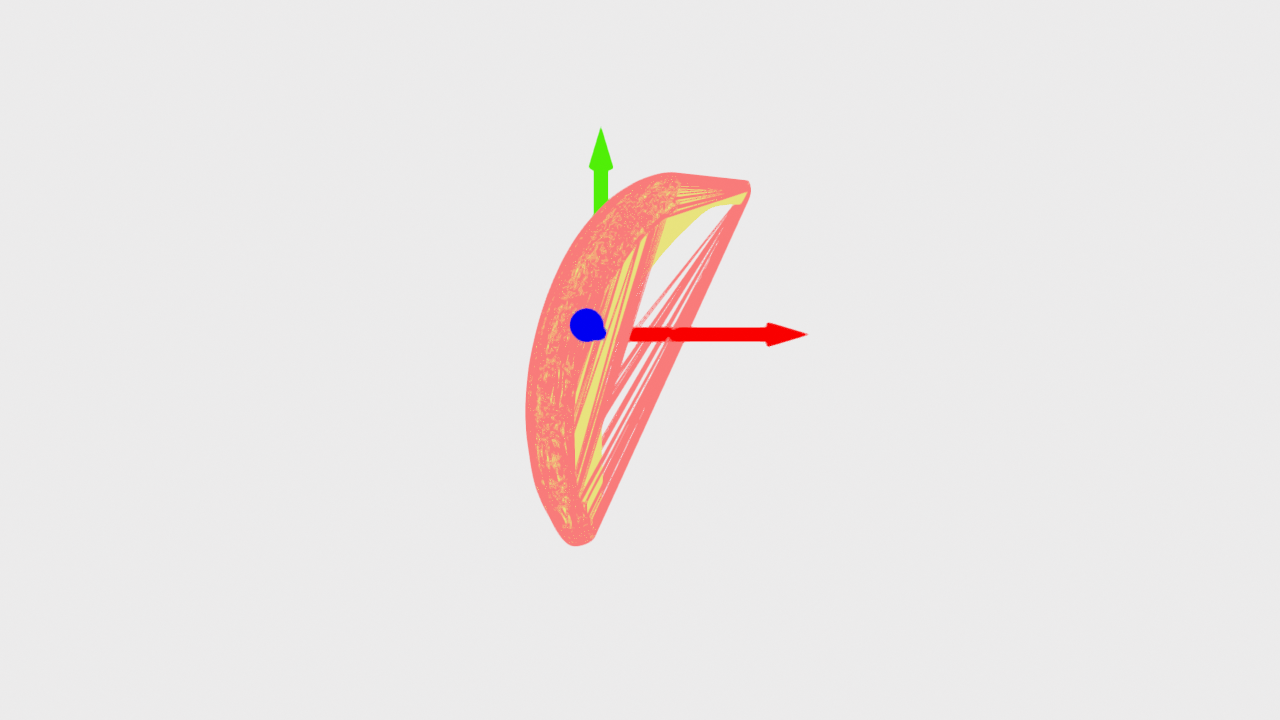

In [12]:
import trimesh, open3d as o3d
import numpy as np
from utils.utils import render_geometries_to_notebook

m = trimesh.load('/home/sbehnam/models/005/textured.obj', force='mesh')
hull = m.convex_hull

# convert to open3d
mesh_o3d = o3d.geometry.TriangleMesh()
mesh_o3d.vertices = o3d.utility.Vector3dVector(m.vertices)
mesh_o3d.triangles = o3d.utility.Vector3iVector(m.faces)
mesh_o3d.paint_uniform_color([0.9, 0.85, 0.2])

hull_o3d = o3d.geometry.TriangleMesh()
hull_o3d.vertices = o3d.utility.Vector3dVector(hull.vertices)
hull_o3d.triangles = o3d.utility.Vector3iVector(hull.faces)
hull_o3d.paint_uniform_color([1.0, 0.2, 0.2])
hull_o3d.compute_vertex_normals()

# render with hull semi-transparent looking — actually open3d doesn't do alpha well,
# easier: render hull as wireframe
hull_wire = o3d.geometry.LineSet.create_from_triangle_mesh(hull_o3d)
hull_wire.paint_uniform_color([1.0, 0.2, 0.2])

render_geometries_to_notebook([mesh_o3d, hull_wire], view='top', zoom=1.4)

In [13]:
# decompose_banana.py
import coacd, trimesh
m = trimesh.load('/home/sbehnam/models/005/nontextured.stl', force='mesh')
parts = coacd.run_coacd(coacd.Mesh(m.vertices, m.faces), threshold=0.05)
for i, (v, f) in enumerate(parts):
    trimesh.Trimesh(v, f).export(f'/home/sbehnam/models/005/coacd_part_{i:02d}.stl')
print(f'{len(parts)} parts')

[2026-05-02 16:41:43.979] [CoACD] [info] threshold               0.05
[2026-05-02 16:41:43.979] [CoACD] [info] max # convex hull       -1
[2026-05-02 16:41:43.979] [CoACD] [info] preprocess mode         auto
[2026-05-02 16:41:43.979] [CoACD] [info] preprocess resolution   50
[2026-05-02 16:41:43.979] [CoACD] [info] pca                     false
[2026-05-02 16:41:43.979] [CoACD] [info] mcts max depth          3
[2026-05-02 16:41:43.979] [CoACD] [info] mcts nodes              20
[2026-05-02 16:41:43.979] [CoACD] [info] mcts iterations         150
[2026-05-02 16:41:43.979] [CoACD] [info] merge                   true
[2026-05-02 16:41:43.979] [CoACD] [info] decimate                false
[2026-05-02 16:41:43.979] [CoACD] [info] max_ch_vertex           256
[2026-05-02 16:41:43.979] [CoACD] [info] extrude                 false
[2026-05-02 16:41:43.979] [CoACD] [info] extrude margin          0.01
[2026-05-02 16:41:43.979] [CoACD] [info] approximate mode        ch
[2026-05-02 16:41:43.979] [CoA